# Introduction: What Big Five Is and What the Traits Mean

The Big Five is a personality framework with five broad trait dimensions often abbreviated as OCEAN:

1. **Openness (O):** imagination, curiosity, interest in ideas and novelty.
2. **Conscientiousness (C):** organization, self-discipline, reliability, and goal-directed behavior.
3. **Extraversion (E):** sociability, energy, assertiveness, and tendency to seek stimulation.
4. **Agreeableness (A):** empathy, cooperation, trust, and prosocial orientation.
5. **Neuroticism (N):** emotional instability, stress reactivity, and tendency toward negative affect.

This notebook studies whether each trait can be predicted by the other four traits, and how strong that dependency is.

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
%matplotlib inline

## Data Acquisition: Source and Context

The data comes from online psychometrics test scores (Big Five questionnaire responses).

- Source file: drafts/datasets/big5-dataset.csv
- Structure: item-level responses for Big Five trait questions (A, O, C, E, N) plus additional metadata columns.
- Goal of acquisition step: load the raw response table and prepare it for trait-level modeling.

In [41]:
raw_big5_data = pd.read_csv('drafts/datasets/big5-dataset.csv')
row_count_before_cleaning = len(raw_big5_data)

deduplicated_big5_data = raw_big5_data.drop_duplicates().copy()
row_count_after_deduplication = len(deduplicated_big5_data)

base_clean_big5_data = deduplicated_big5_data.dropna().copy()
row_count_after_missing_value_removal = len(base_clean_big5_data)

print(f'Rows before cleaning: {row_count_before_cleaning}')
print(f'Rows after duplicate removal: {row_count_after_deduplication}')
print(f'Rows after missing-value removal: {row_count_after_missing_value_removal}')

base_clean_big5_data.head()

Rows before cleaning: 19719
Rows after duplicate removal: 19719
Rows after missing-value removal: 19710


,race,age,engnat,gender,hand,source,country,E1,E2,E3,...,O1,O2,O3,O4,O5,O6,O7,O8,O9,O10
0,3,53,1,1,1,1,US,4,2,5,...,4,1,3,1,5,1,4,2,5,5
1,13,46,1,2,1,1,US,2,2,3,...,3,3,3,3,2,3,3,1,3,2
2,1,14,2,2,1,1,PK,5,1,1,...,4,5,5,1,5,1,5,5,5,5
3,3,19,2,2,1,1,RO,2,5,2,...,4,3,5,2,4,2,5,2,5,5
4,11,25,2,2,1,2,US,3,1,3,...,3,1,1,1,3,1,3,1,5,3


## Data Cleaning: Methods Used

Cleaning was performed in two stages:

1. **Base cleaning**
- Removed duplicate rows.
- Removed rows with missing values.

2. **Strict trait-tail cleaning**
- Computed trait totals (A_total, O_total, C_total, E_total, N_total).
- Applied quantile-based filtering on trait totals only:
  - lower bound: 1st percentile
  - upper bound: 97.5th percentile (stricter upper-tail handling)
- Kept rows that satisfy all five trait bounds simultaneously.

Why this method: Q-Q plots showed near-line behavior in the center with tail deviations, so strict tail filtering reduces outlier influence while preserving most observations.

In [42]:
big5_with_trait_totals = base_clean_big5_data.copy()

trait_item_prefix_by_total_column = {
    'A_total': '^A\\d',
    'O_total': '^O\\d',
    'C_total': '^C\\d',
    'E_total': '^E\\d',
    'N_total': '^N\\d'
}

for trait_total_column, item_regex in trait_item_prefix_by_total_column.items():
    trait_item_columns = big5_with_trait_totals.filter(regex=item_regex)
    big5_with_trait_totals[trait_total_column] = trait_item_columns.sum(axis=1)

trait_total_columns = list(trait_item_prefix_by_total_column.keys())
big5_with_trait_totals[trait_total_columns].describe()

,A_total,O_total,C_total,E_total,N_total
count,19710.000000,19710.000000,19710.000000,19710.000000,19710.000000
mean,32.047742,33.135109,31.547692,30.766058,30.951243
std,3.544088,3.843923,3.885485,3.522607,6.715896
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,31.000000,29.000000,29.000000,26.000000
50%,32.000000,33.000000,32.000000,31.000000,31.000000
75%,34.000000,36.000000,34.000000,33.000000,36.000000
max,50.000000,50.000000,50.000000,50.000000,50.000000


## Data Visualization: What We Plotted and What We Found

We used two main visual diagnostics:

1. **Histograms** for A_total, O_total, C_total, E_total, N_total to inspect shape and spread.
2. **Q-Q plots** for each trait total to compare empirical quantiles with theoretical normal quantiles.

Main finding from visualization:
- The points are nearly on the reference line for most of the distribution.
- Small departures appear at the tails (top and bottom), consistent with outliers/extreme values.
- This directly motivated stricter tail cleaning before modeling.

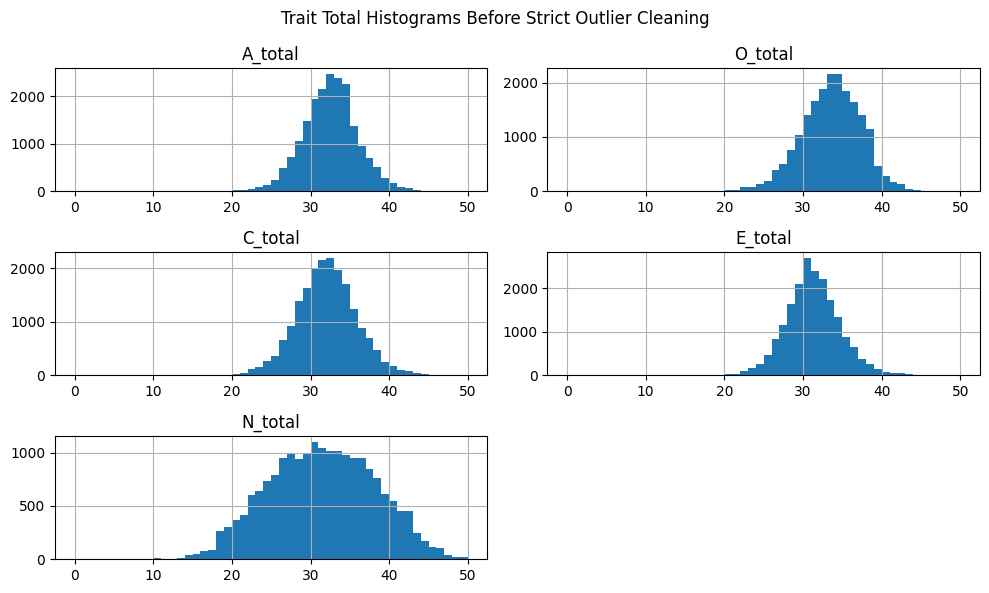

In [43]:
big5_with_trait_totals[trait_total_columns].hist(bins='auto', figsize=(10, 6))
plt.suptitle('Trait Total Histograms Before Strict Outlier Cleaning')
plt.tight_layout()
plt.show()

## Data Visualization Follow-up: Before vs After Strict Cleaning

After strict tail cleaning and z-score standardization:

- Trait ranges become tighter and less tail-heavy.
- Correlation structure remains mostly small-to-moderate, indicating partial overlap but not near-total redundancy.
- Visualization results support moving forward with linear models and repeated hypothesis testing.

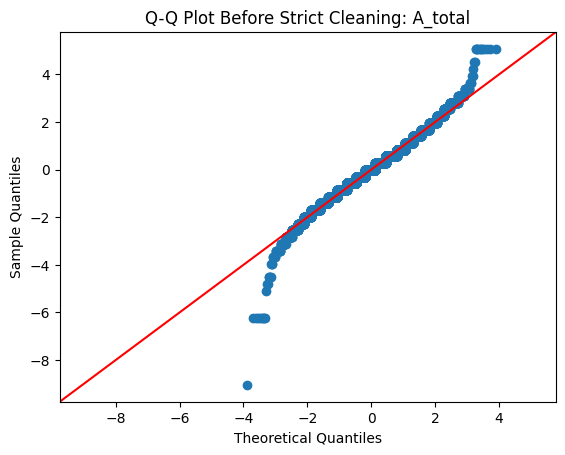

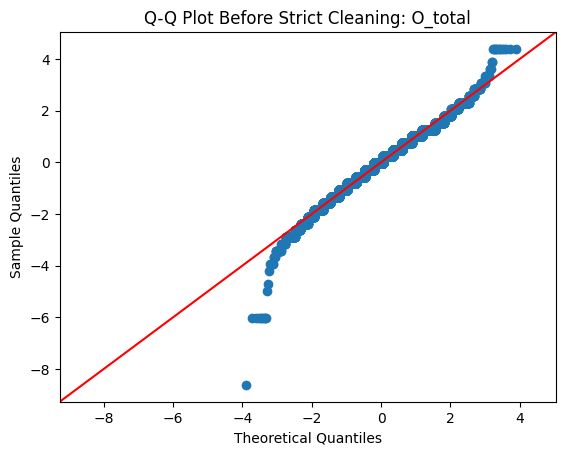

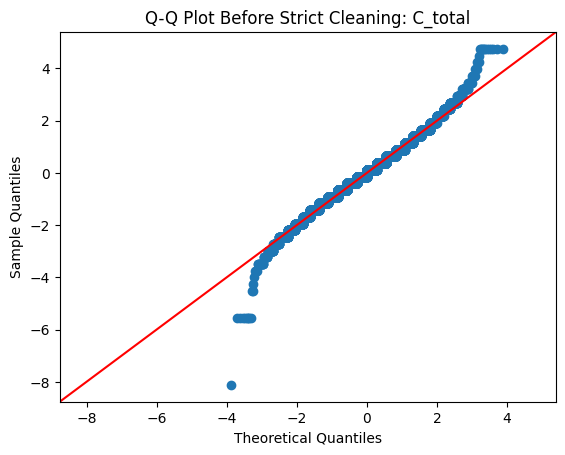

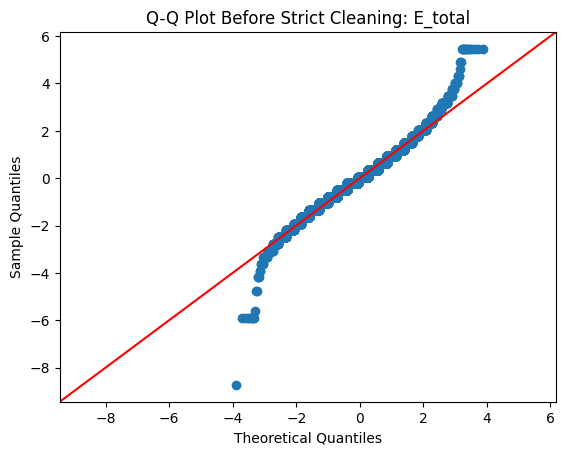

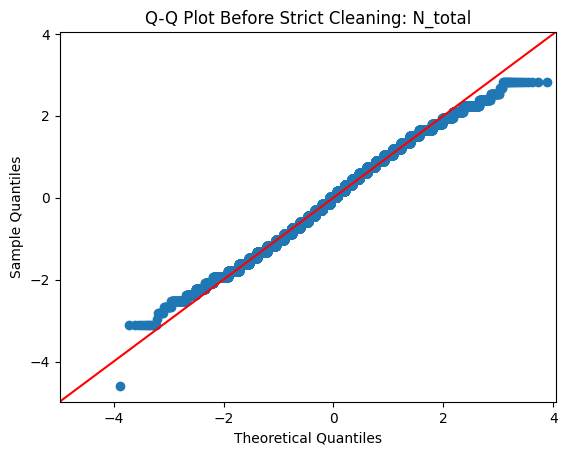

In [44]:
for trait_total_column in trait_total_columns:
    sm.qqplot(big5_with_trait_totals[trait_total_column], line='45', fit=True)
    plt.title(f'Q-Q Plot Before Strict Cleaning: {trait_total_column}')
    plt.show()

## Data Cleaning Output Check

This section reports:

- row count before strict tail cleaning,
- row count after strict tail cleaning,
- percent removed,
- summary statistics after z-score standardization.

These checks verify that cleaning is strict but controlled, and that modeling uses standardized features.

In [45]:
trait_totals_for_cleaning = big5_with_trait_totals[trait_total_columns].dropna().copy()

lower_tail_quantile = 0.01
upper_tail_quantile = 0.975

lower_tail_bounds = trait_totals_for_cleaning.quantile(lower_tail_quantile)
upper_tail_bounds = trait_totals_for_cleaning.quantile(upper_tail_quantile)

is_above_lower_bounds = trait_totals_for_cleaning.ge(lower_tail_bounds, axis=1)
is_below_upper_bounds = trait_totals_for_cleaning.le(upper_tail_bounds, axis=1)
is_within_strict_trait_bounds = (is_above_lower_bounds & is_below_upper_bounds).all(axis=1)

strict_clean_trait_totals = trait_totals_for_cleaning.loc[is_within_strict_trait_bounds].copy()

rows_before_strict_cleaning = len(trait_totals_for_cleaning)
rows_after_strict_cleaning = len(strict_clean_trait_totals)
rows_removed_by_strict_cleaning = rows_before_strict_cleaning - rows_after_strict_cleaning
pct_removed_by_strict_cleaning = (rows_removed_by_strict_cleaning / rows_before_strict_cleaning) * 100

print(f'Rows before strict trait cleaning: {rows_before_strict_cleaning}')
print(f'Rows after strict trait cleaning: {rows_after_strict_cleaning}')
print(f'Rows removed by strict trait cleaning: {rows_removed_by_strict_cleaning} ({pct_removed_by_strict_cleaning:.2f}%)')

trait_scaler = StandardScaler()
standardized_trait_totals = pd.DataFrame(
    trait_scaler.fit_transform(strict_clean_trait_totals),
    columns=trait_total_columns,
    index=strict_clean_trait_totals.index
)

standardized_trait_totals.describe().T[['mean', 'std', 'min', 'max']]

Rows before strict trait cleaning: 19710
Rows after strict trait cleaning: 17387
Rows removed by strict trait cleaning: 2323 (11.79%)


,mean,std,min,max
A_total,-2.970982e-16,1.000029,-2.860128,2.316442
O_total,9.186749e-16,1.000029,-2.654451,2.053741
C_total,2.942375e-16,1.000029,-2.752716,2.267429
E_total,-4.192885e-16,1.000029,-2.806537,2.406950
N_total,2.288514e-16,1.000029,-2.214044,2.024014


## Model Training: 80/20 Holdout Validation

We train linear regression models to predict each target trait from the other four traits.

**Packages used:**
- scikit-learn (LinearRegression, train_test_split, r2_score)
- statsmodels (OLS for inferential testing)
- pandas and numpy (data handling)

**Method:**
1. Split standardized trait data into 80% training and 20% testing.
2. For each target trait (A, O, C, E, N), fit a model using the other four traits.
3. Evaluate both train R2 and test R2.

**Why this model:**
- Linear regression is interpretable.
- Coefficients can be used directly for dependency interpretation.
- OLS framework provides statistical tests for predictor importance.

In [46]:
train_trait_data, test_trait_data = train_test_split(
    standardized_trait_totals,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

holdout_model_records = []

for target_trait_column in trait_total_columns:
    predictor_trait_columns = [
        column_name for column_name in trait_total_columns
        if column_name != target_trait_column
    ]

    training_predictors = train_trait_data[predictor_trait_columns]
    training_target = train_trait_data[target_trait_column]
    testing_predictors = test_trait_data[predictor_trait_columns]
    testing_target = test_trait_data[target_trait_column]

    holdout_model = LinearRegression()
    holdout_model.fit(training_predictors, training_target)

    training_predictions = holdout_model.predict(training_predictors)
    testing_predictions = holdout_model.predict(testing_predictors)

    holdout_model_records.append({
        'target': target_trait_column,
        'train_rows': len(train_trait_data),
        'test_rows': len(test_trait_data),
        'train_r2': r2_score(training_target, training_predictions),
        'test_r2': r2_score(testing_target, testing_predictions)
    })

holdout_validation_summary_df = pd.DataFrame(holdout_model_records).sort_values('target').reset_index(drop=True)
holdout_validation_summary_df

,target,train_rows,test_rows,train_r2,test_r2
0,A_total,13909,3478,0.073345,0.072634
1,C_total,13909,3478,0.071069,0.091449
2,E_total,13909,3478,0.049842,0.056916
3,N_total,13909,3478,0.038401,0.036924
4,O_total,13909,3478,0.042731,0.064379


## Model Training Results and Meaning

From holdout validation and repeated sampling:

- Train and test R2 values are generally modest.
- Typical explanatory power stays in a limited range, indicating partial predictability, not complete predictability.
- This pattern suggests Big Five traits share some information but still retain distinct variance components.

Interpretation:
- If models had very high R2, traits would be strongly redundant.
- Observed modest R2 implies traits are related but not interchangeable.

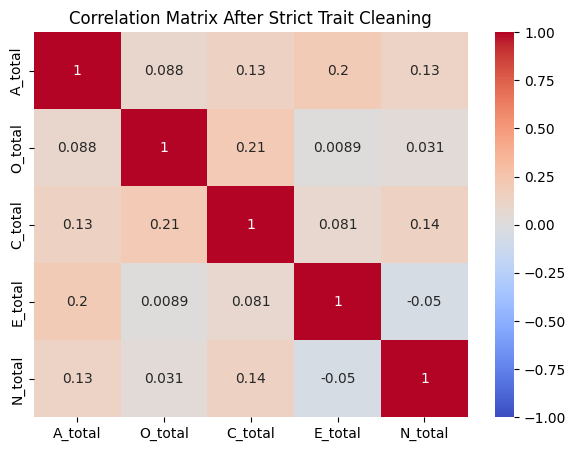

,A_total,O_total,C_total,E_total,N_total
A_total,1.000000,0.087804,0.133597,0.202491,0.125700
O_total,0.087804,1.000000,0.207634,0.008924,0.031290
C_total,0.133597,0.207634,1.000000,0.081084,0.139723
E_total,0.202491,0.008924,0.081084,1.000000,-0.049864
N_total,0.125700,0.031290,0.139723,-0.049864,1.000000


In [47]:
trait_correlation_matrix = standardized_trait_totals.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(trait_correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix After Strict Trait Cleaning')
plt.show()

trait_correlation_matrix

## Model Training (All-Trait Coefficient Table)

This section fits all target-on-others models on the standardized cleaned data and returns:

- coefficient for each predictor-trait pair,
- intercept,
- in-sample R2.

This table is used as a fast structural view of dependency direction and relative magnitude before inferential testing.

In [48]:
all_target_weight_records = []

for target_trait_column in trait_total_columns:
    predictor_trait_columns = [
        column_name for column_name in trait_total_columns
        if column_name != target_trait_column
    ]
    predictor_data = standardized_trait_totals[predictor_trait_columns]
    target_data = standardized_trait_totals[target_trait_column]

    linear_regression_model = LinearRegression()
    linear_regression_model.fit(predictor_data, target_data)

    for predictor_trait_column, model_weight in zip(predictor_trait_columns, linear_regression_model.coef_):
        all_target_weight_records.append({
            'target': target_trait_column,
            'predictor': predictor_trait_column,
            'weight': model_weight,
            'intercept': linear_regression_model.intercept_,
            'train_r2': linear_regression_model.score(predictor_data, target_data)
        })

all_target_weights_df = pd.DataFrame(all_target_weight_records)
all_target_weights_df = all_target_weights_df.sort_values(['target', 'predictor']).reset_index(drop=True)
all_target_weights_df

,target,predictor,weight,intercept,train_r2
0,A_total,C_total,0.087003,-3.251968e-16,0.073220
1,A_total,E_total,0.200925,-3.251968e-16,0.073220
2,A_total,N_total,0.121556,-3.251968e-16,0.073220
3,A_total,O_total,0.064143,-3.251968e-16,0.073220
4,C_total,A_total,0.086806,1.401409e-16,0.075316
5,C_total,E_total,0.068050,1.401409e-16,0.075316
6,C_total,N_total,0.126089,1.401409e-16,0.075316
7,C_total,O_total,0.195459,1.401409e-16,0.075316
8,E_total,A_total,0.205667,-3.400470e-16,0.051348
9,E_total,C_total,0.069814,-3.400470e-16,0.051348


## Hypothesis Testing: Are Traits Really Independent?

### Define the null hypothesis
For each target trait model and each predictor coefficient, we test:

- **H0:** coefficient = 0 (predictor contributes no linear dependency for that target, conditional on other predictors).
- **H1:** coefficient != 0 (predictor contributes non-zero dependency).

Note on wording: in regression testing, coefficient = 0 corresponds to no detectable dependency contribution for that predictor in that model.

### Choose a test
We use two equivalent inferential views for each predictor:

1. coefficient p-value from the full OLS model,
2. partial F-test p-value from reduced-vs-full model comparison.

### Set significance levels
We evaluate decisions at:

- alpha = 0.10
- alpha = 0.05
- alpha = 0.01

### Compute critical values
Decision can be made either by p-values or by critical values:

- p-value rule: reject H0 if p-value <= alpha.
- critical-value rule (equivalent):
  - for coefficient tests: compare |t| with t critical,
  - for nested model tests: compare F with F critical.

This notebook uses the p-value implementation while preserving the same statistical decision boundary.

### Make decisions at each significance level
For every target-predictor pair across repeated samples:

1. compute the non-significance rate at each alpha,
2. summarize mean coefficient and coefficient variability,
3. summarize partial R2 and its confidence interval.

Interpretation guide:
- If coefficient is near 0 and non-significance rate is high across alpha levels, evidence supports weak dependency contribution.
- If p-values are often significant and partial R2 is larger, the predictor has meaningful dependency contribution.
- Use all three alpha levels to see how robust predictor importance is under stricter evidence thresholds.

In [49]:
significance_levels = [0.10, 0.05, 0.01]
number_of_repetitions = 500
random_sample_size = 70
random_seed = 42
practical_partial_r2_threshold = 0.01

if len(standardized_trait_totals) < random_sample_size:
    raise ValueError(
        f'Not enough rows for sample size {random_sample_size}. '
        f'Available rows: {len(standardized_trait_totals)}'
    )

random_generator = np.random.default_rng(random_seed)
repeated_ols_result_records = []
sampling_audit_records = []

for repetition_index in range(number_of_repetitions):
    sampled_row_indices = random_generator.choice(
        standardized_trait_totals.index.to_numpy(),
        size=random_sample_size,
        replace=False
    )
    sampled_trait_data = standardized_trait_totals.loc[sampled_row_indices].reset_index(drop=True)

    sampling_audit_records.append({
        'repetition': repetition_index,
        'sample_size': len(sampled_row_indices),
        'unique_rows_in_sample': len(np.unique(sampled_row_indices))
    })

    for target_trait_column in trait_total_columns:
        predictor_trait_columns = [
            column_name for column_name in trait_total_columns
            if column_name != target_trait_column
        ]
        target_vector = sampled_trait_data[target_trait_column]

        full_design_matrix = sm.add_constant(sampled_trait_data[predictor_trait_columns])
        full_ols_model = sm.OLS(target_vector, full_design_matrix).fit()
        residual_sum_squares_full = float(np.sum(full_ols_model.resid ** 2))

        for removed_predictor_column in predictor_trait_columns:
            reduced_predictor_columns = [
                column_name for column_name in predictor_trait_columns
                if column_name != removed_predictor_column
            ]
            reduced_design_matrix = sm.add_constant(sampled_trait_data[reduced_predictor_columns])
            reduced_ols_model = sm.OLS(target_vector, reduced_design_matrix).fit()
            residual_sum_squares_reduced = float(np.sum(reduced_ols_model.resid ** 2))

            numerator_degrees_of_freedom = 1
            denominator_degrees_of_freedom = int(full_ols_model.df_resid)

            numerator_component = max(
                (residual_sum_squares_reduced - residual_sum_squares_full) / numerator_degrees_of_freedom,
                0.0
            )
            denominator_component = (
                residual_sum_squares_full / denominator_degrees_of_freedom
                if denominator_degrees_of_freedom > 0 else np.nan
            )
            partial_f_statistic = (
                numerator_component / denominator_component
                if denominator_component and not np.isnan(denominator_component) else np.nan
            )
            partial_f_p_value = (
                stats.f.sf(partial_f_statistic, numerator_degrees_of_freedom, denominator_degrees_of_freedom)
                if not np.isnan(partial_f_statistic) else np.nan
            )

            partial_r2_value = (
                (residual_sum_squares_reduced - residual_sum_squares_full) / residual_sum_squares_reduced
                if residual_sum_squares_reduced > 0 else np.nan
            )
            partial_r2_value = max(partial_r2_value, 0.0) if not np.isnan(partial_r2_value) else np.nan

            repeated_ols_result_records.append({
                'repetition': repetition_index,
                'target': target_trait_column,
                'predictor': removed_predictor_column,
                'coefficient': full_ols_model.params[removed_predictor_column],
                'coefficient_p_value': full_ols_model.pvalues[removed_predictor_column],
                'partial_f_statistic': partial_f_statistic,
                'partial_f_p_value': partial_f_p_value,
                'partial_r2': partial_r2_value,
                'model_r2': full_ols_model.rsquared,
                'model_adj_r2': full_ols_model.rsquared_adj
            })

sampling_audit_df = pd.DataFrame(sampling_audit_records)
if len(sampling_audit_df) != number_of_repetitions:
    raise AssertionError('Sampling did not produce the expected number of repetitions.')
if not (sampling_audit_df['sample_size'] == random_sample_size).all():
    raise AssertionError('At least one sample did not contain exactly 70 rows.')
if not (sampling_audit_df['unique_rows_in_sample'] == random_sample_size).all():
    raise AssertionError('At least one sample contains duplicated rows.')

repeated_ols_results_df = pd.DataFrame(repeated_ols_result_records)

print(f'Repetition audit: {len(sampling_audit_df)} samples generated with {random_sample_size} rows each.')
repeated_ols_results_df.head()

Repetition audit: 500 samples generated with 70 rows each.


,repetition,target,predictor,coefficient,coefficient_p_value,partial_f_statistic,partial_f_p_value,partial_r2,model_r2,model_adj_r2
0,0,A_total,O_total,0.251635,0.040400,4.374171,0.040400,0.063052,0.136383,0.083237
1,0,A_total,C_total,0.091187,0.411287,0.683857,0.411287,0.010411,0.136383,0.083237
2,0,A_total,E_total,0.245078,0.034222,4.678701,0.034222,0.067147,0.136383,0.083237
3,0,A_total,N_total,0.103098,0.406441,0.698228,0.406441,0.010628,0.136383,0.083237
4,0,O_total,A_total,0.250569,0.040400,4.374171,0.040400,0.063052,0.197796,0.148429


In [50]:
def compute_mean_and_ci(values, alpha=0.05):
    values_array = np.asarray(values, dtype=float)
    values_array = values_array[~np.isnan(values_array)]
    sample_count = len(values_array)

    if sample_count < 2:
        return np.nan, np.nan, np.nan

    mean_value = values_array.mean()
    standard_error = stats.sem(values_array, nan_policy='omit')
    critical_t_value = stats.t.ppf(1 - alpha / 2, df=sample_count - 1)

    ci_lower_bound = mean_value - critical_t_value * standard_error
    ci_upper_bound = mean_value + critical_t_value * standard_error

    return mean_value, ci_lower_bound, ci_upper_bound

summary_records = []

for (target_trait_column, predictor_trait_column), grouped_results in repeated_ols_results_df.groupby(['target', 'predictor']):
    coefficient_mean = grouped_results['coefficient'].mean()
    coefficient_std = grouped_results['coefficient'].std(ddof=1)

    partial_r2_mean, partial_r2_ci_lower, partial_r2_ci_upper = compute_mean_and_ci(
        grouped_results['partial_r2'].values
    )

    summary_row = {
        'target': target_trait_column,
        'predictor': predictor_trait_column,
        'coefficient_mean': coefficient_mean,
        'coefficient_std': coefficient_std,
        'partial_r2_mean': partial_r2_mean,
        'partial_r2_ci_low_95': partial_r2_ci_lower,
        'partial_r2_ci_high_95': partial_r2_ci_upper,
        'practical_non_importance': (
            bool(partial_r2_ci_upper < practical_partial_r2_threshold)
            if not np.isnan(partial_r2_ci_upper) else False
        )
    }

    for significance_level in significance_levels:
        summary_row[f'non_sig_rate_coef_p(alpha={significance_level})'] = (
            grouped_results['coefficient_p_value'] > significance_level
        ).mean()
        summary_row[f'non_sig_rate_partial_f(alpha={significance_level})'] = (
            grouped_results['partial_f_p_value'] > significance_level
        ).mean()

    summary_records.append(summary_row)

repeated_ols_summary_df = pd.DataFrame(summary_records)
repeated_ols_summary_df = repeated_ols_summary_df.sort_values(['target', 'predictor']).reset_index(drop=True)
repeated_ols_summary_df

,target,predictor,coefficient_mean,coefficient_std,partial_r2_mean,partial_r2_ci_low_95,partial_r2_ci_high_95,practical_non_importance,non_sig_rate_coef_p(alpha=0.1),non_sig_rate_partial_f(alpha=0.1),non_sig_rate_coef_p(alpha=0.05),non_sig_rate_partial_f(alpha=0.05),non_sig_rate_coef_p(alpha=0.01),non_sig_rate_partial_f(alpha=0.01)
0,A_total,C_total,0.086657,0.129625,0.024224,0.021573,0.026874,False,0.790,0.790,0.886,0.886,0.966,0.966
1,A_total,E_total,0.194619,0.125402,0.054554,0.050066,0.059041,False,0.518,0.518,0.632,0.632,0.822,0.822
2,A_total,N_total,0.125334,0.122775,0.032119,0.028887,0.035351,False,0.718,0.718,0.810,0.810,0.928,0.928
3,A_total,O_total,0.059149,0.132490,0.021613,0.019123,0.024103,False,0.830,0.830,0.910,0.910,0.970,0.970
4,C_total,A_total,0.089530,0.132233,0.024224,0.021573,0.026874,False,0.790,0.790,0.886,0.886,0.966,0.966
5,C_total,E_total,0.057598,0.126556,0.019324,0.016862,0.021786,False,0.850,0.850,0.916,0.916,0.974,0.974
6,C_total,N_total,0.127532,0.121930,0.031414,0.028176,0.034653,False,0.716,0.716,0.822,0.822,0.940,0.940
7,C_total,O_total,0.198917,0.122340,0.055393,0.050742,0.060045,False,0.506,0.506,0.620,0.620,0.804,0.804
8,E_total,A_total,0.204795,0.129913,0.054554,0.050066,0.059041,False,0.518,0.518,0.632,0.632,0.822,0.822
9,E_total,C_total,0.059827,0.129158,0.019324,0.016862,0.021786,False,0.850,0.850,0.916,0.916,0.974,0.974


## Results and Findings: What the Output Means

### Main numeric findings
- Repeated model R2 and adjusted R2 are modest across targets.
- Holdout (80/20) test R2 values are also modest, which supports generalization of the same conclusion.
- Sampling audit confirms the repeated procedure used 500 random samples of size 70.

### Meaning
1. The traits are not perfectly independent in empirical data because there is non-zero shared predictability.
2. The traits are not strongly redundant because explained variance remains limited.
3. The best interpretation is: **related but still meaningfully distinct personality dimensions**.

### Practical interpretation of hypothesis tests
- High non-significance rates and near-zero coefficients indicate weak predictor importance for a target trait.
- Lower non-significance rates and larger effect summaries indicate stronger dependency contribution.
- Conclusions should be framed as evidence strength, not absolute proof.

In [51]:
overall_target_model_summary_df = (
    repeated_ols_results_df.groupby('target')[['model_r2', 'model_adj_r2']]
    .agg(['mean', 'std'])
)
overall_target_model_summary_df

model_r2           model_adj_r2          
             mean       std         mean       std
target                                            
A_total  0.130350  0.068473     0.076833  0.072687
C_total  0.130899  0.067885     0.077416  0.072062
E_total  0.104598  0.062632     0.049497  0.066487
N_total  0.095527  0.056943     0.039867  0.060447
O_total  0.107686  0.063327     0.052775  0.067224